### The goal of this project is to begin investigating why attrition might be occuring in our employee base.

In [69]:
# Source of the data:

# import kagglehub

# # downloading latest version
# path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

# print("Path to dataset files:", path)

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import babel as bl
from scipy import stats
from babel import numbers

In [6]:
#1: loading the dataset
data = pd.read_csv('/Users/brtelfer/Documents/Personal Stuff/Python Data Projects/1_Employee Attrition Prediction/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df = pd.DataFrame(data)
df.select_dtypes(include=['number']).columns.tolist()

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [7]:
#1: setting attrition to 0 and 1 for analysis
data_copy = data.copy()
data_copy['Attrition'] = data_copy['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
data_copy['Attrition']

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [8]:
#2: Next, I will perform the pd.get_dummies function on all of the categorical data.
# This is a form of one-hot encoding. drop_first=True will be used to avoid the risk of multicollinearity
dummy_data = pd.get_dummies(data_copy, columns=['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime'], drop_first=True)
dummy_data.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_1',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturin

In [9]:
#3 First, I ensure 'Attrition' is already properly encoded (from cell 44)
data['Attrition'] = data['Attrition'].map({'Yes': 1, 'No': 0})  # Or however you encoded it earlier

#4: Then I Identify categorical columns (excluding 'Attrition' and 'EmployeeNumber')
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

#5: I Apply one-hot encoding to categorical features
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

#6: Now I will separate features and target
X = data.drop(['Attrition', 'EmployeeNumber'], axis=1)  # Drop target and ID column
y = data['Attrition']

In [10]:
#7: Now that the data is ready, I will import the required scikit-learn tools:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [11]:
#8: and split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#9: then initialize and fit the logistic regression model:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/opt/anaconda3/envs/Remote_Work_Env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
#10: Finally, I will use the model to make predictions:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8707482993197279
Confusion Matrix:
 [[249   6]
 [ 32   7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.54      0.18      0.27        39

    accuracy                           0.87       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.84      0.87      0.84       294



In [13]:
# so, we can say that the precision and accuracy are quite high.

In [37]:
# Now, we will perform a decision tree analysis.
#1: First by re-reading the data in:
data = pd.read_csv("/Users/brtelfer/Documents/Personal Stuff/Python Data Projects/1_Employee Attrition Prediction/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [38]:
#2: For decision trees, all of the data must be numerical. 
# Therefore, we must either convert all of the data into a numerical format,
# or, only run the analysis on numerical data
# First, we have to get a list of all the non-numerical columns in the dataset
# and then, we must get the unique values, and use map() to convert them into numbers

In [46]:
data.select_dtypes(exclude=['number']).head(3)

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes


In [ ]:
OverTime_Key = {'OverTime': {'Yes': 1, 'No': 0}}
# A key for our safekeeping
OverTime_Key

{'OverTime': {'Yes': 1, 'No': 0}}

In [50]:
data['OverTime'] = data['OverTime'].replace('Yes', 1)
data['OverTime'] = data['OverTime'].replace('No', 0)

/var/folders/_q/6b8w1jdj7r90hq2bqrt7k8fw0000gn/T/ipykernel_65273/939887506.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['OverTime'] = data['OverTime'].replace('No', 0)


In [52]:
data['OverTime'].head(3)

0    1
1    0
2    1
Name: OverTime, dtype: int64

In [66]:
# I could include the rest in a further analysis but will exclude for now.
features = data.select_dtypes(include=['number']).columns.to_list()

In [65]:
#3: # In this case, our features are everything except for attrition 
# for the sake of simplicity, we will also drop the initial numerical data

#4 Define X (features) and y (target)
X = data[features]
y = data['Attrition']

In [67]:
#5: Now that we have prepared our data, we must import the required libraries:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

[Text(0.5, 0.8333333333333334, 'OverTime <= 0.5\ngini = 0.27\nsamples = 1470\nvalue = [1233.0, 237.0]'),
 Text(0.25, 0.5, 'TotalWorkingYears <= 2.5\ngini = 0.187\nsamples = 1054\nvalue = [944, 110]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.442\nsamples = 88\nvalue = [59, 29]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.154\nsamples = 966\nvalue = [885, 81]'),
 Text(0.75, 0.5, 'MonthlyIncome <= 2475.0\ngini = 0.424\nsamples = 416\nvalue = [289.0, 127.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.423\nsamples = 69\nvalue = [21, 48]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.352\nsamples = 347\nvalue = [268, 79]')]

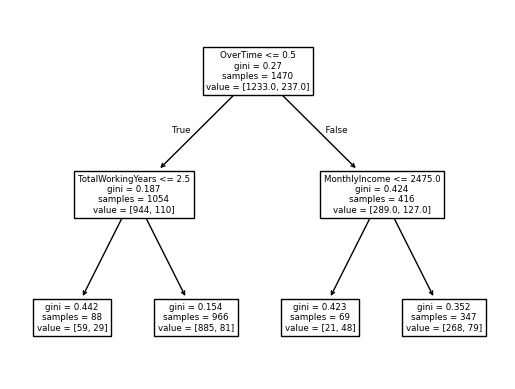

In [68]:
#6: Finally, we are ready to run our analysis:
dtree = DecisionTreeClassifier(max_depth=2)
dtree = dtree.fit(X, y)

tree.plot_tree(dtree, feature_names=features)

In [1]:
# according to this, people with low experience AND no overtime are more mixed in their outcomes
# yet people with more experience and no overtime are very likely to stay.
# Although, those with low income and overtime are more likely to leave.

### From this, I would reccomend further investigating the relationship between pay and overtime for those with lower income to see if there are any perceived conflicts.